# Implementation of the 3D Segmentation Method by S. Gauthier et al.

This notebook presents my proof-of-concept implementation of the 3D object segmentation method proposed by **S. Gauthier et al.** in their paper:

> Gauthier, S., Puech, W., Bénière, R., & Subsol, G. (2017). *Digitized 3D mesh segmentation based on curvature analysis.*  
> Electronic Imaging, 2017(20), 33–38. https://doi.org/10.2352/ISSN.2470-1173.2017.20.3DIPM-005

The goal of this work is to reproduce, in Python, the main steps of the method.

---

## Objectives

This segmentation method is based on local curvature analysis. With this approach, we aim to automatically determine a threshold for edge detection by analyzing the distribution of curvatures within the part. Once the edges are detected, the regions are identified using region growing algorithm.

The main steps of the code will go as follow:

0. Import the necessary libraries.
1. Load the .stl file and extract relevant data for segmentation: vertices, their normals, their 2-ring neighbors, and the mean edge length.
2. Compute the local curvature at each vertex of the mesh.
3. Analyze the curvature distribution to determine edge detection thresholds.
4. Perform the segmentation process.
5. Evaluate the performance of the algorithm on a .stl file.



## 0. Libraries
For this code, the following libraries are required:
- `numpy`
- `numpy-stl` (we use the `mesh` class)
- `matplotlib` (we use the module `matplotlib.pyplot`and the function `Poly3DCollection`)
- `scipy` (specifically `scipy.optimize.curve_fit` )
- `math` (we use `cos`, `sin`, and `atan2`)
- `time` (if you want to measure the execution time of the algorithm)


In [1]:
import numpy as np
from stl import mesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.optimize import curve_fit
from math import cos, sin, atan2
import time

----

## 1. STL File Loading and Mesh Data Extraction

The STL file is loaded using `mesh.Mesh.from_file`, which provides the coordinates of the points defining each triangle of the mesh, as well as the corresponding triangle normals. At this stage, vertices are stored per triangle, which results in duplicated vertex coordinates in `stl_file.vectors`.

The function `extract_mesh_data(stl_mesh)` enables to return the set of **unique** vertices, their normals, their neighborhood, and the mean edge length of the mesh.

An index mapping is used to associate each vertex coordinate with a unique index. This mapping enables also efficient construction of vertex neighborhoods.

Vertex normals are computed as the normalized sum of the normals of all triangles incident to each vertex.

For neighborhood definition, a 2-ring neighborhood is considered instead of a 1-ring neighborhood. Although no specific choice is imposed in the reference article, using a 2-ring neighborhood provides a larger set of neighboring points for the local curvature estimation which relies on a curve fitting (see Step 2).

Finally, the mean edge length of the mesh is computed and used to normalize curvature values in Step 2.





In [11]:
## STEP 1 : Load STL File, Extract Vertices, their Normals, their 2-Ring Neighbours and the Mean Edge Length
file_path = r"stl_files\LURPart.stl"
stl_mesh = mesh.Mesh.from_file(file_path)

# extract vertices, their normals, their 2-ring neighbours, and the mean edge length
def extract_mesh_data(stl_mesh):
    points = stl_mesh.vectors.reshape(-1, 3)
    face_normals = np.repeat(stl_mesh.normals, 3, axis=0)

    vertices = []  # list of unique vertices
    normals = []   # n = (Σ adjacent face normals)/||Σ adjacent face normals||
    index_map = {} # to map vertex coordinates to their index in vertices list

    for i, v in enumerate(points):
        key = tuple(v)
        if key not in index_map:
            index_map[key] = len(vertices)
            vertices.append(points[i])
            normals.append(face_normals[i])
        else:
            idx = index_map[key]
            normals[idx] = normals[idx] + face_normals[i]

    for i in range(len(normals)):
        normals[i] = normals[i] / np.linalg.norm(normals[i]) # normalisation of normals

    # 1-ring neighbours search + mean edge length calculation
    neighbours_1r = [[] for _ in range(len(vertices))]
    triangles = stl_mesh.vectors.reshape(-1, 3, 3) 
    mean_edge_lengths = 0
    n_edges = 0
    for tri in triangles:
        idx0 = index_map[tuple(tri[0])]
        idx1 = index_map[tuple(tri[1])]
        idx2 = index_map[tuple(tri[2])]

        if idx1 not in neighbours_1r[idx0]:
            neighbours_1r[idx0].append(idx1)
        if idx2 not in neighbours_1r[idx0]:
            neighbours_1r[idx0].append(idx2)

        if idx0 not in neighbours_1r[idx1]:
            neighbours_1r[idx1].append(idx0)
        if idx2 not in neighbours_1r[idx1]:
            neighbours_1r[idx1].append(idx2)

        if idx0 not in neighbours_1r[idx2]:
            neighbours_1r[idx2].append(idx0)
        if idx1 not in neighbours_1r[idx2]:
            neighbours_1r[idx2].append(idx1)

        # edge lengths
        mean_edge_lengths += np.linalg.norm(tri[0] - tri[1])
        mean_edge_lengths += np.linalg.norm(tri[1] - tri[2])
        mean_edge_lengths += np.linalg.norm(tri[2] - tri[0])
        n_edges += 3
    mean_edge_lengths /= n_edges 

    # 2-ring neighbours search - they are the neighbours of the 1-ring neighbours
    neighbours_2r = []
    for i in range(len(vertices)):
        two_ring = set(neighbours_1r[i])
        for j in neighbours_1r[i]:
            two_ring.update(neighbours_1r[j])
        two_ring.discard(i)  # to remove the vertex itself
        neighbours_2r.append(list(two_ring))

    return vertices, normals, neighbours_2r, mean_edge_lengths, index_map

('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
plt.show()

Here is what we get for the LURPart :

Vertices coordinates:
[[22.632748 33.20274  18.08303 ]
 [22.145649 32.544308 18.3453  ]
 [22.267048 32.6762   19.046772]
 [22.632748 33.20274  19.119343]
 [22.925598 33.97703  19.019232]]

Vertices normals coordinates:
[[-8.6128187e-01  5.0812399e-01  1.8625853e-03]
 [-6.9322705e-01  7.2067797e-01  7.7066417e-03]
 [-7.6611960e-01  6.4269775e-01 -5.5083429e-04]
 [-9.0567958e-01  4.2395332e-01 -2.8432629e-03]
 [-9.6978879e-01  2.4394618e-01 -2.8035903e-04]]

Each vertices (2-ring) neighbors indices:
Vertex 0: [1, 2, 3, 4, 5, 9, 10, 15, 10528, 1058, 1059, 1205, 1206, 1207, 1378, 1379, 1251, 1253, 1252, 10492]
Vertex 1: [0, 2, 1379, 1378, 1253, 5, 3, 1251, 9, 10, 10528, 1381, 1380, 1377, 10546, 1205, 1206]
Vertex 2: [0, 1, 3, 4, 5, 9, 10, 11, 12, 15, 1205, 1206, 1377, 1378, 1379, 1253, 1381, 1388]
Vertex 3: [0, 1, 2, 4, 5, 9, 10, 11, 12, 14, 15, 19, 1184, 1058, 1059, 1205, 1206, 1378, 1253, 10492]
Vertex 4: [0, 1184, 2, 1059, 3, 5, 1058, 1057, 10, 12, 14, 15, 19, 1206, 10492]

Mean edge le

<bound method _AxesBase.set_xlabel of <Axes3D: >>

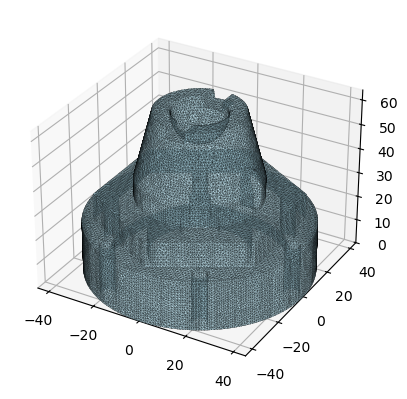

In [34]:
vertices, normals, neighbours, mean_edge_length, _ = extract_mesh_data(stl_mesh)
vertices = np.array(vertices)
normals = np.array(normals)
print("Vertices coordinates:")
print(vertices[:5])
print("\nVertices normals coordinates:")
print(normals[:5])
print("\nEach vertices (2-ring) neighbors indices:")
for i in range(5):
    print(f"Vertex {i}: {neighbours[i]}")
print(f"\nMean edge length of the mesh: {mean_edge_length:.4f} unit lengths")

# Visualization of the mesh
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
triangles = stl_mesh.vectors
ax.add_collection3d(Poly3DCollection(triangles, facecolor='lightblue', linewidths=0.1, edgecolor='k', alpha=0.5))
points = triangles.reshape(-1, 3)
ax.set_xlim(points[:,0].min(), points[:,0].max())
ax.set_ylim(points[:,1].min(), points[:,1].max())
ax.set_zlim(points[:,2].min(), points[:,2].max())
ax.set_xlabel

----

## 2. Local Curvature Computation

In this step, the local curvature is estimated at each vertex of the mesh based on its geometric neighborhood. 

The function `local_curvature` computes the curvature at a vertex $P$ with normal $N$, using its neighbors and their associated normals:
- For each neighbor $P_i$, a directional curvature $k_i$ is computed along the tangent direction $t_i$. The curvature in this direction is computed as:

$$
k_i = \frac{\langle P_i - P, N_i - N \rangle}{\|P_i - P\|^2},
$$

where $N_i$ is the normal of $P_i$. This directional curvature is evaluated for all neighbors of the vertex.

- Then, we use the curvature model from Chen and Schmitt [X. Chen and F. Schmitt, *Intrinsic surface properties from surface triangulation*, pages 739–743, Springer Berlin Heidelberg, 1992] to estimate the principal curvature $k_1$ (denoted `k_max` in the code) via curve fitting:

$$
k(\phi) = k_1 \cos^2(\phi - \phi_1) + k_2 \sin^2(\phi - \phi_1),
$$

- If the curve fitting fails to converge, the maximum value among the computed directional curvatures $k_i$ is retained.

The function `compute_curvatures` applies this local curvature estimation to all vertices of the mesh.



In [21]:
## STEP 2 : Compute Local Curvature at Each Vertex of the Mesh
# Compute local curvature at a vertex P given its normal N and its 2-ring neighbours
def local_curvature(vertex, normal, neighbors, neighbor_normals):
    # curvature at P in the direction t_i defined by neighbor i :
    # k_i(t_i) = <(P_i - P), (N_i - N)> / ||P_i - P||^2
    # to approximate the principal curvatures k_1 and k_2, we use the relation :
    # k(phi) = k_1 * cos^2(phi) + k_2 * sin^2(phi)
    # -> phi : angle between t_i and a reference direction t_1
    
    P = vertex
    N = normal

    ki_list = [] 
    ti_list = [] 
    phii_list = [] 

    if len(neighbors) < 3:
        return 0.0  # not enough neighbors to compute curvature

    for i in range(len(neighbors)):
        Pi = neighbors[i]
        Ni = neighbor_normals[i]
        di = Pi - P
        ti = (di - np.dot(di, N) * N) / np.linalg.norm(di - np.dot(di, N) * N)
        ki = (np.dot(di, Ni - N)) / (np.linalg.norm(di)**2)

        if len(ti_list) == 0:
            phii = 0.0
        else:
            ref = ti_list[0]
            phii = atan2(np.dot(ti, np.cross(N, ref)), np.dot(ti, ref))


        ki_list.append(ki)
        ti_list.append(ti)
        phii_list.append(phii)

    # Curve fitting to find k_max, k_min, phi_max
    def curvature_model(phi, k1, k2, phi1):
        return k1 * np.cos(phi - phi1)**2 + k2 * np.sin(phi - phi1)**2
    try:
        res, _ = curve_fit(
            curvature_model,
            phii_list,
            ki_list,
            p0=[max(ki_list), min(ki_list), 0],
            maxfev=5000
        )
        k_max, k_min, phi_max = res
    except Exception: # if curve fitting fails
        k_max = max(ki_list)

    return k_max

# Compute curvatures for all vertices
def compute_curvatures(stl_mesh):
    vertices, normals, neighbours, mean_edge_lengths, index_map = extract_mesh_data(stl_mesh)
    normalised_curvatures = []
    for i in range(len(vertices)):
        P = vertices[i]
        N = normals[i]
        neighbors = [vertices[j] for j in neighbours[i]]
        neighbor_normals = [normals[j] for j in neighbours[i]]

        k = local_curvature(P, N, neighbors, neighbor_normals)
        normalised_curvatures.append(k*mean_edge_lengths) # normalisation with the mean edge length

    return vertices, normalised_curvatures, index_map

Here is a visualization of the curvatures over the part. Triangles are colored according to the mean curvature of their vertices :

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20940\159662839.py:42: OptimizeWarning: Covariance of the parameters could not be estimated
  res, _ = curve_fit(


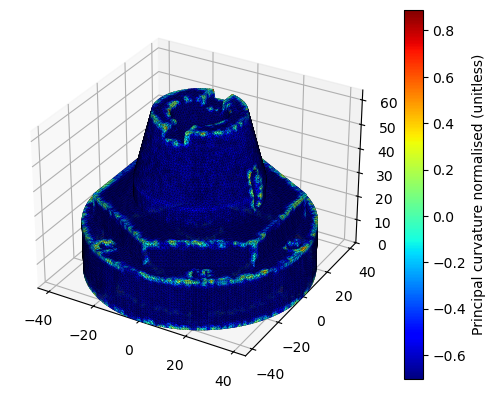

: 

In [ ]:
# Visualization of curvatures on the 3D mesh 
def plot_curvature_3d_triangles(stl_mesh):
    vertices, curvatures, index_map = compute_curvatures(stl_mesh)
    v = np.array(vertices)
    k = np.array(curvatures)
    # mean curvature per triangle
    triangles = stl_mesh.vectors
    triangle_curvatures = np.array([
        np.mean([k[index_map[tuple(tri[i])]] for i in range(3)])
        for tri in triangles
    ])

    # plot
    cmap = plt.get_cmap("jet")
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    colors = cmap(triangle_curvatures)
    poly_collection = Poly3DCollection(triangles, facecolors=colors, edgecolor='k', linewidths=0.1)
    ax.add_collection3d(poly_collection)

    ax.set_xlim(v[:,0].min(), v[:,0].max())
    ax.set_ylim(v[:,1].min(), v[:,1].max())
    ax.set_zlim(v[:,2].min(), v[:,2].max())

    mappable = plt.cm.ScalarMappable(cmap=cmap)
    mappable.set_array(triangle_curvatures)
    cbar = plt.colorbar(mappable, ax=ax)
    cbar.set_label("Principal curvature normalised (unitless)")

    plt.show()

plot_curvature_3d_triangles(stl_mesh)

It can be observed that the edges stand out clearly due to their distinct curvature values, but also that the triangles with these curvature values are fewer.

----

## 3. Analysis of Curvature Distribution for Thresholding

The core of this method is to analyze the distribution of curvatures in order to automatically determine a threshold for edge detection. Yet, there are still some parameters to adjust manually.

The function `plot_curvature_distribution` enables plotting the discrete distribution of curvatures, normalized by multiplying them by the mean edge length.. The number of bins `n_bins` needs to be adjusted: more bins provide finer resolution but may introduce noise, while fewer bins smooth the histogram. 

Next, we compute a continuous approximation of this histogram using kernel density estimation. To do so, there is a parameter `h` to adjust: if it is too small, it introduces noise, while if it is too large, it can overly smooth the distribution and lose information.

The function `analyze_distribution` identifies peaks and valleys in the distribution with the aim of detecting edges. Peaks are defined as local maxima within a sliding window (the size of the window is set with `window_size`), and valleys are determined as the farthest point from the line connecting consecutive peaks. Small adjustments are applied at the distribution extremities, and only one valley is retained between each pair of peaks. Moreover, extreme valleys with density below the threshold `min_density` are filtered out; I added this filtering because, in some cases, all vertices would otherwise be incorrectly labeled as uniform and no edges would be detected, as the edges were numerous enough to generate extreme peaks that would be mistakenly identified.




C:\Users\ASUS\AppData\Local\Temp\ipykernel_20940\2746959973.py:42: OptimizeWarning: Covariance of the parameters could not be estimated
  res, _ = curve_fit(


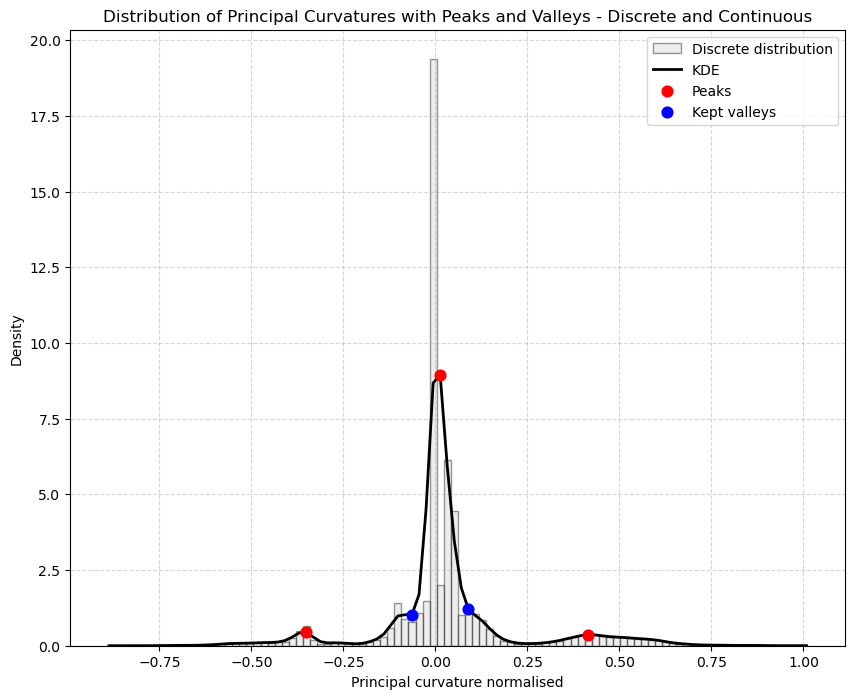

In [ ]:
## STEP 3 : Analysis of the distribution of curvatures
# Distribution of normalised curvatures (k_max * mean_edge_length) -> discrete histogram
def plot_curvature_distribution(curvatures, bins=50, filename="results/distibution_discrete.png"):
    plt.figure(figsize=(10,6))
    plt.hist(curvatures, bins=bins, color='grey', edgecolor='black')
    plt.title("Distribution of Principal Curvatures (Normalised)")
    plt.xlabel(f"Principal curvature normalised")
    plt.ylabel("Number of occurrences")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.savefig(filename, dpi=300)
    #plt.show()

# Estimation of curvature distribution using kernel density estimation -> continuous curve
def kernel_estimation(curvatures, n_bins=50, h=0.01, filename="results/distribution_continuous.png"):
    curvatures = np.array(curvatures)

    #plot_curvature_distribution(curvatures, bins=n_bins, filename=f"results/distribution_discrete_n{n_bins}_h{h}.png")
    
    # discrete distribution over bins
    bin_edges = np.linspace(curvatures.min(), curvatures.max(), n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # computation of density estimation using Gaussian kernels
    density = np.zeros_like(bin_centers)
    for xi in curvatures:
        density += np.exp(-0.5 * ((bin_centers - xi)/h)**2) / (h * np.sqrt(2*np.pi))
    density /= density.sum() * (bin_centers[1] - bin_centers[0])

    # visualization
    """ plt.figure(figsize=(10,6))
    plt.plot(bin_centers, density, color='black')
    plt.title("Estimation of Curvature Distribution using KDE")
    plt.xlabel("Principal curvature normalised")
    plt.ylabel("Density")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.savefig(filename, dpi=300)
    plt.show() """
    
    return bin_centers, density

# Analysis of the distribution : identification of peaks and valleys
def analyze_distribution(curvatures, bin_centers, density, window_size=10, n_bins=50, h=0.01, min_density=0.02):
    n_bins = len(bin_centers)

    # Robust peaks detection : maximum in a window
    peaks = []
    for i in range(n_bins):
        start = max(0, i - window_size // 2)
        end = min(n_bins, i + window_size // 2 + 1)
        if density[i] == np.max(density[start:end]):
            peaks.append(i)

    # Filtering peaks with minimum height (0.01% of max density)
    min_peak_height = 0.01 * density.max()
    peaks = [p for p in peaks if density[p] >= min_peak_height]

    if len(peaks) < 1:
        return [], []

    # Addition of artificial peaks for extremities valleys detection
    peaks_ext = []
    density_ext = density.copy()

    # Left Extremity
    left_data = bin_centers[:peaks[0]]
    if len(left_data) > 1:
        mu_l = np.mean(left_data)
        sigma_l = np.std(left_data)
        x_ext_l = mu_l - 3 * sigma_l
    else:
        x_ext_l = bin_centers[0]
    idx_ext_l = np.argmin(np.abs(bin_centers - x_ext_l))
    peaks_ext.append(idx_ext_l)
    peaks_ext.extend(peaks)
    density_ext[idx_ext_l] = 0


    # Right Extremity
    right_data = bin_centers[peaks[-1]:]
    if len(right_data) > 1:
        mu_r = np.mean(right_data)
        sigma_r = np.std(right_data)
        x_ext_r = mu_r + 3 * sigma_r
    else:
        x_ext_r = bin_centers[-1]
    idx_ext_r = np.argmin(np.abs(bin_centers - x_ext_r))
    peaks_ext.append(idx_ext_r)
    density_ext[idx_ext_r] = 0


    # Robust valleys detection : farthest bin from the line connecting two consecutive peaks
    valleys = []
    for p1, p2 in zip(peaks_ext[:-1], peaks_ext[1:]):
        # line between both peaks : y = m*x + b
        x1, y1 = bin_centers[p1], density_ext[p1]
        x2, y2 = bin_centers[p2], density_ext[p2]
        m = (y2 - y1) / (x2 - x1) if x2 != x1 else 0
        b = y1 - m * x1
        start = min(p1, p2) + 1
        end = max(p1, p2)
        if start >= end:
            continue

        distances = []
        for i in range(start, end):
            y_line = m * bin_centers[i] + b
            distances.append(y_line - density[i])
        distances = np.array(distances)
        
        # if several candidates, keep the one closest to 0
        if len(distances) > 0:
            max_dist_idx = np.argmax(distances)
            candidates = np.where(distances == distances[max_dist_idx])[0]
            best_idx = candidates[np.argmin(np.abs(bin_centers[start:end][candidates]))]
            valleys.append(start + best_idx)

    # Filtering extreme valleys if their density is too low
    filtered_valleys = []
    ignored_valleys = []

    if len(valleys) > 0:
        # Left extreme valley
        if density[valleys[0]] >= min_density * density.max():
            filtered_valleys.append(valleys[0])
        else:
            ignored_valleys.append(valleys[0])

    # All intermediate valleys are always kept
    for v in valleys[1:-1]:
        filtered_valleys.append(v)

    if len(valleys) > 1:
        # Right extreme valley
        if density[valleys[-1]] >= min_density * density.max():
            filtered_valleys.append(valleys[-1])
        else:
            ignored_valleys.append(valleys[-1])

    # Visualization of peaks and valleys
    """ plt.figure(figsize=(10, 6))
    plt.plot(bin_centers, density, color="black", label="Distribution")

    plt.scatter(bin_centers[peaks], density[peaks], color="red", label="Peaks", zorder=3)
    plt.scatter(bin_centers[filtered_valleys], density[filtered_valleys], color="blue", label="Valleys kept", zorder=3)
    ignored_valleys = [v for v in valleys if v not in filtered_valleys]
    plt.scatter(bin_centers[ignored_valleys], density[ignored_valleys], color="grey", label="Valleys ignored", zorder=3)

    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.savefig(f"results/distribution_analysis_n{n_bins}_h{h}.png", dpi=300)
    #plt.show() """

    return peaks, filtered_valleys, ignored_valleys, n_bins, h

_, curvatures,_ = compute_curvatures(stl_mesh)
bin_centers, density = kernel_estimation(curvatures, n_bins=100, h=0.02)
peaks, valleys, ignored_valleys, n_bins, h = analyze_distribution(curvatures, *kernel_estimation(curvatures, n_bins=100, h=0.02), window_size=10, n_bins=100, h=0.02, min_density=0.02)
# Visualization of discrete and continuous distributions with peaks and valleys superimposed
plt.figure(figsize=(10, 8))
plt.hist(curvatures, bins=n_bins, density=True, color="lightgrey", edgecolor="black", alpha=0.4, label="Discrete distribution")
plt.plot(bin_centers, density, color="black", linewidth=2, label="KDE")
plt.scatter(bin_centers[peaks], density[peaks], color="red", s=60, label="Peaks", zorder=3)
plt.scatter(bin_centers[valleys], density[valleys], color="blue", s=60, label="Kept valleys", zorder=3)
ignored_valleys = [v for v in valleys if v not in valleys]
if len(ignored_valleys) > 0:
    plt.scatter(bin_centers[ignored_valleys], density[ignored_valleys], color="grey", s=60, label="Ignored valleys", zorder=3)
plt.xlabel("Principal curvature normalised")
plt.ylabel("Density")
plt.title("Distribution of Principal Curvatures with Peaks and Valleys - Discrete and Continuous")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig(f"results/distribution_discrete_analysis_n{n_bins}_h{h}.png", dpi=300)
plt.show()

We can observe that vertices with zero curvature are indeed the most numerous, resulting in the very large peak at 0. 

The edges correspond to points with the highest absolute curvature values, which appear here at the peaks near the distribution extremities. Therefore, the thresholds to separate edges from uniform regions should be set at the intermediate valleys.

Note that the parameters `h`, `n_bins`, and `window_size` are sensitive. It required several iterations to identify the right combination that preserves the essential information, namely the valleys that allow separating edges from uniform regions.

----

## 4. Thresholding and Segmentation of the Mesh

In this step, the vertices are first classified as either "edge" or "uniform" based on the previous analysis of the curvatures, then a region-growing algorithm is applied to perform the mesh segmentation.. 

The function `thresholding` defines curvature thresholds using the first and last valleys detected in Step 3. Vertices with curvature values outside this range are labeled as "edge", and vertices within the thresholds are labeled as "uniform".

The function `segmentation` works as follow :

a. **Triangle Labeling:** Each triangle is labeled as "edge" or "uniform" based on the labels of its vertices. Following the approach of the reference article, a triangle is considered an edge if the edge label is dominant among its vertices. This criterion may be slightly restrictive but is in accordance with the method described in the reference article...

b. **Region Growing:** To identify connected triangles forming uniform regions, an iterative region growing algorithm is applied. Triangle adjacency is determined via shared vertices, and starting from unassigned uniform triangles, each region is expanded by repeatedly adding neighboring uniform triangles until no more neighbors can be added.

c. **Post-Processing of Small Regions:** Small regions whose total area is below a threshold (20 times the mean triangle area, as suggested in the article) are either merged with neighboring regions or removed if no unique neighbor exists.

d. **Erosion/Dilation Post-Processing:** To enhance the segmentation, erosion is first applied to remove connections between regions that should be separate. A second region growing is then performed on the remaining uniform triangles. Finally, the same number of dilations as erosions is applied to restore the size of the regions. The number of erosion/dilation iterations is controlled by the parameter `n_erosions` and has to be tuned as well.

The idea here is that, at the end of c., there may be an under-segmentation (fewer regions detected than expected). Step d. then aims to separate regions that were mistakenly merged.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20940\2746959973.py:42: OptimizeWarning: Covariance of the parameters could not be estimated
  res, _ = curve_fit(


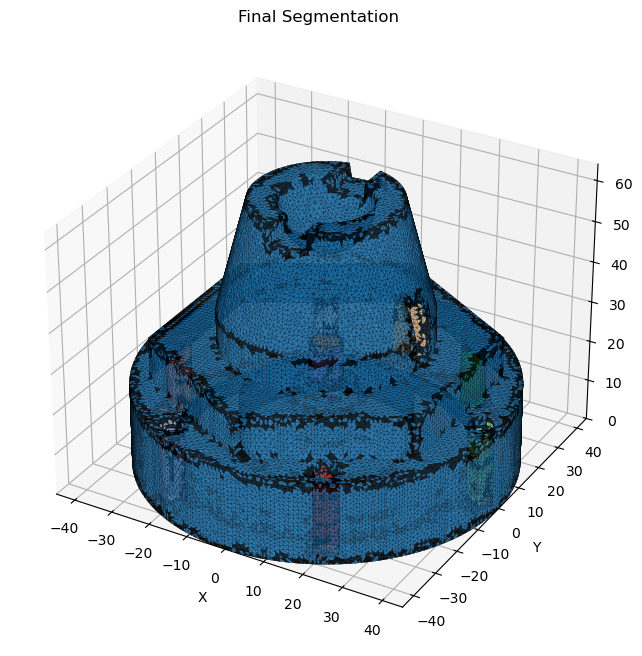

Curvature thresholds used for segmentation: -0.1930 and 0.0751
Number of regions identified: 10
Segmentation executed in 56.30 seconds.


In [27]:
# Automatic definition of curvature thresholds based on the distribution analysis, corresponding to the first and last valleys
def thresholding(vertices, curvatures, n_bins=50, h=0.01, window_size=10, min_density=0.02):
    vertices = np.array(vertices)
    curvatures = np.array(curvatures)

    # Kernel estimation of the curvature distribution
    bin_centers, density = kernel_estimation(curvatures, n_bins=n_bins, h=h)
    # Detection of peaks and valleys
    peaks, valleys, ignored_valleys, n_bins, h = analyze_distribution(curvatures, bin_centers, density, window_size=window_size, n_bins=n_bins, h=h, min_density=min_density)
    if len(valleys) < 2:
        raise ValueError("Not enough valleys.")

    # Thresholds based on the first and last valleys
    first_valley_idx = valleys[0] # we keep the 1st valley
    last_valley_idx = valleys[-1] # and the last valley
    threshold_low = bin_centers[first_valley_idx]
    threshold_high = bin_centers[last_valley_idx]

    # Vertices labeling
    labels = []
    for k in curvatures:
        if threshold_low <= k <= threshold_high:
            labels.append("uniform")
        else:
            labels.append("edge")
    labels = np.array(labels)

    #print(f"Thresholds : {threshold_low:.4f} and {threshold_high:.4f}")

    # Visualization of the mesh after thresholding
    """ colors = np.array(['blue' if label == 'uniform' else 'red' for label in labels])
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(vertices[:,0], vertices[:,1], vertices[:,2], c=colors, s=5)
    ax.set_xlim(vertices[:,0].min(), vertices[:,0].max())
    ax.set_ylim(vertices[:,1].min(), vertices[:,1].max())
    ax.set_zlim(vertices[:,2].min(), vertices[:,2].max())
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    plt.title(" Classification of vertices : uniform (blue) vs edge (red)")
    plt.show()"""

    return labels, threshold_low, threshold_high 

# Segmentation function, using a region growing algorithm
def segmentation(stl_mesh, n_bins=50, h=0.01, window_size=10, min_density=0.02, n_erosions=5):
    start_time = time.perf_counter()
    # Compute curvatures
    vertices, curvatures, index_map = compute_curvatures(stl_mesh)
    
    # Thresholding to label vertices as 'uniform' or 'edge'
    labels, threshold_low, threshold_high = thresholding(vertices, curvatures, n_bins=n_bins, h=h, window_size=window_size, min_density=min_density)

    triangles = stl_mesh.vectors
    n_triangles = len(triangles)

    def triangle_area(tri):
        return 0.5 * np.linalg.norm(np.cross(tri[1] - tri[0], tri[2] - tri[0]))
    triangle_areas = np.array([triangle_area(tri) for tri in triangles])
    mean_triangle_area = np.mean(triangle_areas)
    area_threshold = 20 * mean_triangle_area 

    # Labelling triangles
    triangle_labels = []
    for tri in triangles:
        indices = [index_map[tuple(v)] for v in tri]
        tri_vertex_labels = [labels[idx] for idx in indices]
        if tri_vertex_labels.count("edge") >= 2:
            triangle_labels.append("edge")
        else:
            triangle_labels.append("uniform")
    triangle_labels = np.array(triangle_labels)

    # Triangle adjacency
    triangle_neighbors = [[] for _ in range(n_triangles)]
    vertex_to_triangles = {i: [] for i in range(len(vertices))}
    for t_idx, tri in enumerate(triangles):
        for v in tri:
            vertex_to_triangles[index_map[tuple(v)]].append(t_idx)
    for t_idx, tri in enumerate(triangles):
        neighbor_set = set()
        for v in tri:
            neighbor_set.update(vertex_to_triangles[index_map[tuple(v)]])
        neighbor_set.discard(t_idx)
        triangle_neighbors[t_idx] = list(neighbor_set)

    # Initial region growing on uniform triangles
    region_ids = -1 * np.ones(n_triangles, dtype=int)
    current_region = 0
    for t_idx in range(n_triangles):
        if triangle_labels[t_idx] != "uniform" or region_ids[t_idx] != -1:
            continue
        stack = [t_idx]
        while stack:
            curr = stack.pop()
            if region_ids[curr] != -1:
                continue
            region_ids[curr] = current_region
            for nbr in triangle_neighbors[curr]:
                if triangle_labels[nbr] == "uniform" and region_ids[nbr] == -1:
                    stack.append(nbr)
        current_region += 1

    # Post-processing small regions
    region_ids_post = region_ids.copy()
    unique_regions = np.unique(region_ids[region_ids >= 0])
    for r in unique_regions:
        tris = np.where(region_ids == r)[0]
        area = triangle_areas[tris].sum()
        if area < area_threshold:
            neighbors = set()
            for t in tris:
                for n in triangle_neighbors[t]:
                    if region_ids[n] != r and region_ids[n] != -1:
                        neighbors.add(region_ids[n])
            if len(neighbors) == 1:
                target = neighbors.pop()
                region_ids_post[tris] = target
            else:
                region_ids_post[tris] = -1
    region_ids = region_ids_post
    current_region = len(np.unique(region_ids[region_ids >= 0]))
    #print(f"Number of regions after post-processing (before erosion/dilation) : {current_region}")

    # Visualization of the initial segmentation
    """ cmap = plt.get_cmap("tab20")
    colors = []
    for t in range(n_triangles):
        if region_ids[t] == -1:
            colors.append((0, 0, 0, 0.7))  # edges
        else:
            colors.append(cmap(region_ids[t] % 20))
    colors = np.array(colors)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    poly_collection = Poly3DCollection(triangles, facecolors=colors, edgecolor='k', linewidths=0.1, alpha=0.7)
    ax.add_collection3d(poly_collection)
    v = np.array(vertices)
    ax.set_xlim(v[:,0].min(), v[:,0].max())
    ax.set_ylim(v[:,1].min(), v[:,1].max())
    ax.set_zlim(v[:,2].min(), v[:,2].max())
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    plt.title("Initial Segmentation")
    plt.show() """

    ### Post-processing to enhance the segmentation : Erosion/Dilatation
    # Erosion
    mask = (region_ids != -1)
    for _ in range(n_erosions):
        new_mask = mask.copy()
        for t in range(n_triangles):
            if not mask[t]:
                continue
            same = sum(mask[n] for n in triangle_neighbors[t])
            if same < 3:
                new_mask[t] = False
        mask = new_mask

    # Region growing on eroded regions
    region_ids = -1 * np.ones(n_triangles, dtype=int)
    current_region = 0
    for t_idx in range(n_triangles):
        if not mask[t_idx] or region_ids[t_idx] != -1:
            continue
        stack = [t_idx]
        while stack:
            curr = stack.pop()
            if region_ids[curr] != -1:
                continue
            region_ids[curr] = current_region
            for nbr in triangle_neighbors[curr]:
                if mask[nbr] and region_ids[nbr] == -1:
                    stack.append(nbr)
        current_region += 1

    # Visualization after erosion + region growing
    """ cmap = plt.get_cmap("tab20")
    colors = []
    for t in range(n_triangles):
        if region_ids[t] == -1:
            colors.append((0, 0, 0, 0.7))
        else:
            colors.append(cmap(region_ids[t] % 20))
    colors = np.array(colors)
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    poly = Poly3DCollection(triangles, facecolors=colors, edgecolor='k', linewidths=0.1, alpha=0.9)
    ax.add_collection3d(poly)
    v = np.array(vertices)
    ax.set_xlim(v[:, 0].min(), v[:, 0].max())
    ax.set_ylim(v[:, 1].min(), v[:, 1].max())
    ax.set_zlim(v[:, 2].min(), v[:, 2].max())
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    plt.title("Segmentation after erosion and second region growing")
    plt.tight_layout()
    plt.show() """

    # Dilatation
    for _ in range(n_erosions):
        new_region_ids = region_ids.copy()
        for t in range(n_triangles):
            if region_ids[t] != -1:
                continue
            neighbor_regions = [region_ids[n] for n in triangle_neighbors[t] if region_ids[n] != -1]
            if len(neighbor_regions) == 1:
                new_region_ids[t] = neighbor_regions[0]
        region_ids = new_region_ids

    n_regions_after = len(np.unique(region_ids[region_ids >= 0]))
    #print(f"Number of regions after erosion/dilation : {n_regions_after}")

    end_time = time.perf_counter()
    elapsed_time = end_time - start_time

    # Final visualization of the segmentation
    cmap = plt.get_cmap("tab20")
    colors = []
    for t in range(n_triangles):
        if region_ids[t] == -1:
            colors.append((0, 0, 0, 0.7))
        else:
            colors.append(cmap(region_ids[t] % 20))
    colors = np.array(colors)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    poly_collection = Poly3DCollection(triangles, facecolors=colors, edgecolor='k', linewidths=0.1, alpha=0.7)
    ax.add_collection3d(poly_collection)
    v = np.array(vertices)
    ax.set_xlim(v[:, 0].min(), v[:, 0].max())
    ax.set_ylim(v[:, 1].min(), v[:, 1].max())
    ax.set_zlim(v[:, 2].min(), v[:, 2].max())
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    plt.title("Final Segmentation")
    plt.show()


    return region_ids, triangle_labels, threshold_low, threshold_high, elapsed_time

region_ids,_, threshold_low, threshold_high, execution_time = segmentation(stl_mesh, n_bins=200, h=0.01, window_size=8, min_density=0.02, n_erosions=6)

print(f"Curvature thresholds used for segmentation: {threshold_low:.4f} and {threshold_high:.4f}")
print(f"Number of regions identified: {len(np.unique(region_ids[region_ids >= 0]))}")
print(f"Segmentation executed in {execution_time:.2f} seconds.")

Here, for the LURPart mesh, with the following parameters 
- `n_bins = 200`  
- `h = 0.01`  
- `window_size = 8`  
- `min_density = 0.02`  
- `n_erosions = 6`  
the segmentation is imperfect (run the `curvature_based_segmentation` code directly to visualize it in 3D). 
The six holes are correctly identified, but despite the erosion/dilation steps, the outer surfaces are not fully separated.




With a slight modification to the algorithm, the results for the outer surface can be a bit improved. 
By labeling a triangle as 'edge' if at least one of its vertices is classified as such, the edge boundaries are reinforced, as more triangles are considered part of the edges. Then the region growing is less likely to merge regions by mistake.

The same set of parameters is used in the following case.

Now, the outer surface is better segmented, but some unfortunate merges remain. However, we have an over-segmentation for some regions underneath the part. This is not desirable because the method from the reference article does not include any post-processing to merge regions that should be connected.

Remark: with this alternative function and `h = 0.02`, all regions are well separated, but the over-segmentation issue is even more pronounced.



C:\Users\ASUS\AppData\Local\Temp\ipykernel_20940\2746959973.py:42: OptimizeWarning: Covariance of the parameters could not be estimated
  res, _ = curve_fit(


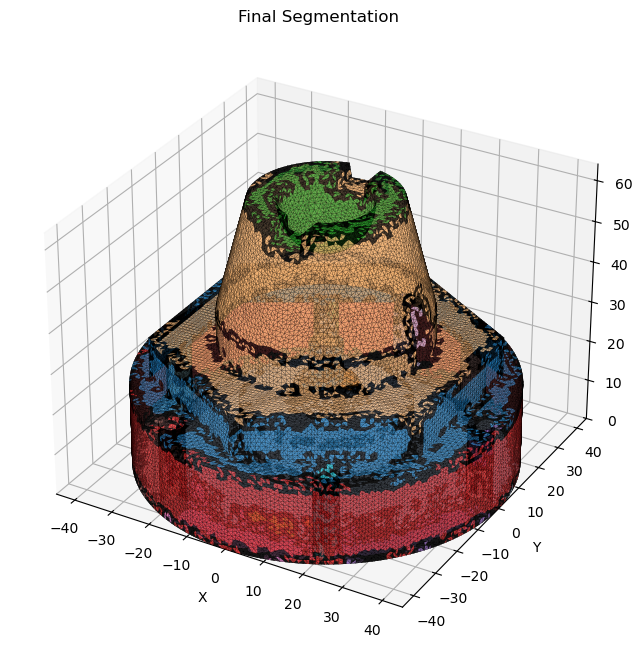

Curvature thresholds used for segmentation: -0.1930 and 0.0751
Number of regions identified: 36
Segmentation executed in 170.09 seconds.


In [32]:
def segmentation_bis(stl_mesh, n_bins=50, h=0.01, window_size=10, min_density=0.02, n_erosions=5):
    start_time = time.perf_counter()
    # Compute curvatures
    vertices, curvatures, index_map = compute_curvatures(stl_mesh)
    
    # Thresholding to label vertices as 'uniform' or 'edge'
    labels, threshold_low, threshold_high = thresholding(vertices, curvatures, n_bins=n_bins, h=h, window_size=window_size, min_density=min_density)

    triangles = stl_mesh.vectors
    n_triangles = len(triangles)

    def triangle_area(tri):
        return 0.5 * np.linalg.norm(np.cross(tri[1] - tri[0], tri[2] - tri[0]))
    triangle_areas = np.array([triangle_area(tri) for tri in triangles])
    mean_triangle_area = np.mean(triangle_areas)
    area_threshold = 20 * mean_triangle_area 

    # Labelling triangles
    triangle_labels = []
    for tri in triangles:
        indices = [index_map[tuple(v)] for v in tri]
        tri_vertex_labels = [labels[idx] for idx in indices]
        if tri_vertex_labels.count("edge") >= 1: ### MODIFIED HERE
            triangle_labels.append("edge")
        else:
            triangle_labels.append("uniform")
    triangle_labels = np.array(triangle_labels)

    # Triangle adjacency
    triangle_neighbors = [[] for _ in range(n_triangles)]
    vertex_to_triangles = {i: [] for i in range(len(vertices))}
    for t_idx, tri in enumerate(triangles):
        for v in tri:
            vertex_to_triangles[index_map[tuple(v)]].append(t_idx)
    for t_idx, tri in enumerate(triangles):
        neighbor_set = set()
        for v in tri:
            neighbor_set.update(vertex_to_triangles[index_map[tuple(v)]])
        neighbor_set.discard(t_idx)
        triangle_neighbors[t_idx] = list(neighbor_set)

    # Initial region growing on uniform triangles
    region_ids = -1 * np.ones(n_triangles, dtype=int)
    current_region = 0
    for t_idx in range(n_triangles):
        if triangle_labels[t_idx] != "uniform" or region_ids[t_idx] != -1:
            continue
        stack = [t_idx]
        while stack:
            curr = stack.pop()
            if region_ids[curr] != -1:
                continue
            region_ids[curr] = current_region
            for nbr in triangle_neighbors[curr]:
                if triangle_labels[nbr] == "uniform" and region_ids[nbr] == -1:
                    stack.append(nbr)
        current_region += 1

    # Post-processing small regions
    region_ids_post = region_ids.copy()
    unique_regions = np.unique(region_ids[region_ids >= 0])
    for r in unique_regions:
        tris = np.where(region_ids == r)[0]
        area = triangle_areas[tris].sum()
        if area < area_threshold:
            neighbors = set()
            for t in tris:
                for n in triangle_neighbors[t]:
                    if region_ids[n] != r and region_ids[n] != -1:
                        neighbors.add(region_ids[n])
            if len(neighbors) == 1:
                target = neighbors.pop()
                region_ids_post[tris] = target
            else:
                region_ids_post[tris] = -1
    region_ids = region_ids_post
    current_region = len(np.unique(region_ids[region_ids >= 0]))
    #print(f"Number of regions after post-processing (before erosion/dilation) : {current_region}")

    # Visualization of the initial segmentation
    """ cmap = plt.get_cmap("tab20")
    colors = []
    for t in range(n_triangles):
        if region_ids[t] == -1:
            colors.append((0, 0, 0, 0.7))  # edges
        else:
            colors.append(cmap(region_ids[t] % 20))
    colors = np.array(colors)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    poly_collection = Poly3DCollection(triangles, facecolors=colors, edgecolor='k', linewidths=0.1, alpha=0.7)
    ax.add_collection3d(poly_collection)
    v = np.array(vertices)
    ax.set_xlim(v[:,0].min(), v[:,0].max())
    ax.set_ylim(v[:,1].min(), v[:,1].max())
    ax.set_zlim(v[:,2].min(), v[:,2].max())
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    plt.title("Initial Segmentation")
    plt.show() """

    ### Post-processing to enhance the segmentation : Erosion/Dilatation
    # Erosion
    mask = (region_ids != -1)
    for _ in range(n_erosions):
        new_mask = mask.copy()
        for t in range(n_triangles):
            if not mask[t]:
                continue
            same = sum(mask[n] for n in triangle_neighbors[t])
            if same < 3:
                new_mask[t] = False
        mask = new_mask

    # Region growing on eroded regions
    region_ids = -1 * np.ones(n_triangles, dtype=int)
    current_region = 0
    for t_idx in range(n_triangles):
        if not mask[t_idx] or region_ids[t_idx] != -1:
            continue
        stack = [t_idx]
        while stack:
            curr = stack.pop()
            if region_ids[curr] != -1:
                continue
            region_ids[curr] = current_region
            for nbr in triangle_neighbors[curr]:
                if mask[nbr] and region_ids[nbr] == -1:
                    stack.append(nbr)
        current_region += 1

    # Visualization after erosion + region growing
    """ cmap = plt.get_cmap("tab20")
    colors = []
    for t in range(n_triangles):
        if region_ids[t] == -1:
            colors.append((0, 0, 0, 0.7))
        else:
            colors.append(cmap(region_ids[t] % 20))
    colors = np.array(colors)
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    poly = Poly3DCollection(triangles, facecolors=colors, edgecolor='k', linewidths=0.1, alpha=0.9)
    ax.add_collection3d(poly)
    v = np.array(vertices)
    ax.set_xlim(v[:, 0].min(), v[:, 0].max())
    ax.set_ylim(v[:, 1].min(), v[:, 1].max())
    ax.set_zlim(v[:, 2].min(), v[:, 2].max())
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    plt.title("Segmentation after erosion and second region growing")
    plt.tight_layout()
    plt.show() """

    # Dilatation
    for _ in range(n_erosions):
        new_region_ids = region_ids.copy()
        for t in range(n_triangles):
            if region_ids[t] != -1:
                continue
            neighbor_regions = [region_ids[n] for n in triangle_neighbors[t] if region_ids[n] != -1]
            if len(neighbor_regions) == 1:
                new_region_ids[t] = neighbor_regions[0]
        region_ids = new_region_ids

    n_regions_after = len(np.unique(region_ids[region_ids >= 0]))
    #print(f"Number of regions after erosion/dilation : {n_regions_after}")

    end_time = time.perf_counter()
    elapsed_time = end_time - start_time

    # Final visualization of the segmentation
    cmap = plt.get_cmap("tab20")
    colors = []
    for t in range(n_triangles):
        if region_ids[t] == -1:
            colors.append((0, 0, 0, 0.7))
        else:
            colors.append(cmap(region_ids[t] % 20))
    colors = np.array(colors)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    poly_collection = Poly3DCollection(triangles, facecolors=colors, edgecolor='k', linewidths=0.1, alpha=0.7)
    ax.add_collection3d(poly_collection)
    v = np.array(vertices)
    ax.set_xlim(v[:, 0].min(), v[:, 0].max())
    ax.set_ylim(v[:, 1].min(), v[:, 1].max())
    ax.set_zlim(v[:, 2].min(), v[:, 2].max())
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    plt.title("Final Segmentation")
    plt.show()


    return region_ids, triangle_labels, threshold_low, threshold_high, elapsed_time


region_ids,_, threshold_low, threshold_high, execution_time = segmentation_bis(stl_mesh, n_bins=200, h=0.01, window_size=8, min_density=0.02, n_erosions=6)

print(f"Curvature thresholds used for segmentation: {threshold_low:.4f} and {threshold_high:.4f}")
print(f"Number of regions identified: {len(np.unique(region_ids[region_ids >= 0]))}")
print(f"Segmentation executed in {execution_time:.2f} seconds.")

## 5. Evaluation of performances

This section presents an evaluation of the performance of this segmentation method. The function used is `segmentation` (and not `segmentation_bis`), since it is the version of the algorithm that is the closest to the method described in the article.

To do so, the segmentation will be applied to the following parts (see `dataset` folder):
- Cylinder with a coarse mesh: `cylinder_coarse.stl`
- Cylinder with a fine mesh: `cylinder_fine.stl`
- A small Lego-like brick: `lego.stl`
- A cylindrical cover with holes: `cover_with_holes.stl`
- The LURPart : `LURPart.stl`

This dataset consists of parts with more or less complex geometries (to get an idea, cf. the number of regions), as well as meshes of different resolutions, in order to evaluate the robustness of the algorithm against different geometric configurations and mesh qualities.
Remark: "low-poly" meshes are not suitable for this method, as the local curvature is approximated from vertex normals and their two-ring neighborhoods. A sufficiently fine and uniform mesh is required to ensure a good estimation of surface curvature.

For each part, we will consider :
- the number of detected regions
- the number of correctly detected regions (not merged with another region nor split)
- the number of regions merged by error
- the number of regions split by error

And we will consider these performance indicators:
- the correctly detected regions rate
- the execution time

For each experiment, it was necessary to tune the following parameters: `n_bins`, `h`, `window_size`, `min_density`, and `n_erosions`.
To do so, I carried out several trials (up to about thirty) by analyzing the result of the distribution analysis in order to find satisfactory parameters. The table below summarizes the results obtained with the parameters giving the best correctly detected regions rate, while avoiding over-segmentation.

In [ ]:
# STEP 5 : Evaluation of performance on an STL file

region_ids, triangle_labels, t_low, t_high, execution_time = segmentation(stl_mesh, n_bins=200, h=0.01, window_size=8, min_density=0.02, n_erosions=6)

print("----- RESULTS -----")
print(f"Number of triangles in the mesh : {len(stl_mesh.vectors)}")
print(f"Execution time : {execution_time:.2f} seconds")
print(f"Thresholds used : {t_low:.4f} and {t_high:.4f}")
print(f"Number of regions found : {len(np.unique(region_ids[region_ids >= 0]))}")

| Test Part | Number of Triangles | n_bins | h | window_size | min_density | n_erosions | Expected Number of Regions | Number of Detected Regions | Correctly Detected Regions | Regions Merged by Error | Regions Split by Error | Correctly Detected Regions Rate | Execution Time |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| Cylinder - Fine Mesh | 11800 | 100 | 0.01 | 10 | 0.1 | 6 | 3 | 2 | 1 | 2 | 0 | 33% | 21.66 |
| Cylinder - Coarse Mesh | 4800 | 120 | 0.01 | 10 | 0.1 | 6 | 3 | 1 | 0 | 3 | 0 | 0% | 10.06 |
| Lego | 30568 | 100 | 0.05 | 10 | 0.02 | 10 | 9 | 1 | 0 | 9 | 0 | 0% | 23.29 |
| Cover | 13980 | 200 | 0.01 | 8 | 0.02 | 6 | 10 | 4 | 2 | 8 | 1 | 20% | 11.13 |
| LURPart | 67674 | 200 | 0.01 | 8 | 0.02 | 6 | 36 | 10 | 8 | 28 | 0 | 22% | 52.79 |

In the `results` folder, you can find the curvature distribution graph with detected peaks and valleys, as well as an image of the segmented part. To inspect the segmentation in detail, run the code with `curvature_based_segmentation.py` and explore it in the 3D viewer.

Regarding the cylinder, the algorithm does not achieve satisfactory segmentation in either case (coarse or fine mesh). Indeed, the edges are not consistently detected across the surface. For the fine mesh, the algorithm manages to segment the back face from the rest of the part, but the top face remains problematic. It appears that the lower threshold (negative) is reasonably well determined, whereas the upper threshold (positive) is not.
As expected, the execution time is shorter for the coarser mesh. The most time-consuming part of the algorithm is indeed the computation of the local curvature at each vertex, as implemented in the `local_curvature` function which has a complexity proportionnal to the number of vertices in the mesh.

It seems that this type of geometry is too simple for this method. Indeed, not only is the density of points that should be labeled as "edge" too low for clear detection, but the curvature distribution may also lack the necessary symmetry (i.e., having both negative and positive curvature values along edges) to define effective thresholds. As a result, edges may not be properly distinguished from uniform regions. For these reasons, the lego part is also not well segmented by the algorithm. Its geometry, while slightly more complex than a simple cylinder, still does not produce sufficiently distinct curvature features for the method to reliably identify edges.

However, it appears that the algorithm performs better on more complex parts with regions exhibiting varied curvature. Indeed, for the cover and the LURPart, the holes can be successfully segmented. However, these holes themselves act as perturbations and can lead to oversegmentation if the parameters are changed (for example, by increasing `h`, which smooths the curvature distribution). The results are particularly satisfactory for the LURPart, which presents a good variety of curvatures across its regions. In both cases, accurately segmenting the outer surface remains challenging, as it tends to merge when trying to avoid oversegmentation.


---

## Conclusion

Thus, the method proposed by the authors for segmentation appears quite challenging to implement in order to achieve good results. Indeed, there are several parameters to adjust, and the segmentation is very sensitive to these settings. Determining the edge detection threshold is therefore not fully automatic.

Moreover, the method relies on assumptions that make it not always relevant depending on the geometry. Specifically, it works well if the part has a rather complex geometry with multiple regions exhibiting varied curvatures, if the point density along edges is significantly lower than the point density on uniform regions, and if the edge curvatures are substantially higher in absolute value than the curvatures of the uniform regions.

A slight modification of the algorithm, as implemented in `segmentation_bis`, can help improve the segmentation in some cases, by labeling a triangle as an 'edge' if at least one of its vertices is classified as such.

All in all, it would be valuable to clearly identify the cases in which the algorithm reaches its limits, and to determine robust parameter settings that perform reliably across different geometries. At present, the number of tunable parameters makes it difficult to achieve consistent results. Reducing this number to two or three would make the algorithm more practical, while still preserving its ability to adapt to a variety of shapes and curvature distribution patterns.
